In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns


In [2]:
dataset = pd.read_csv("./datasets/Mall_Customers.csv")
dataset.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


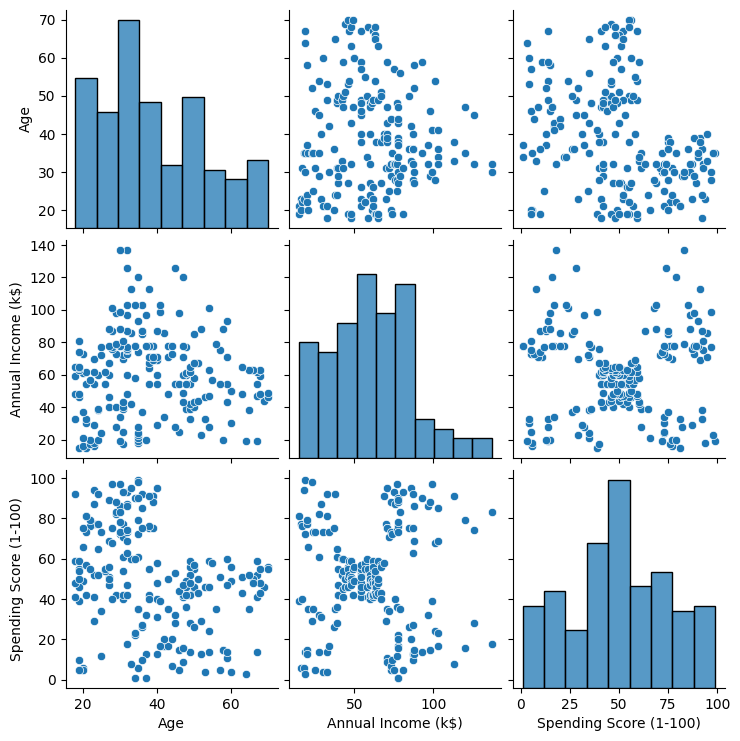

In [4]:
sns.pairplot(dataset[["Age", "Annual Income (k$)", "Spending Score (1-100)"]])

In [5]:
# Выбор признаков
X_income_spending = dataset[["Annual Income (k$)", "Spending Score (1-100)"]].values
X_age_spending = dataset[["Age", "Spending Score (1-100)"]].values
X = dataset[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].values


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_income_spending)
X_scaled


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [7]:
RANDOM_STATE = 42

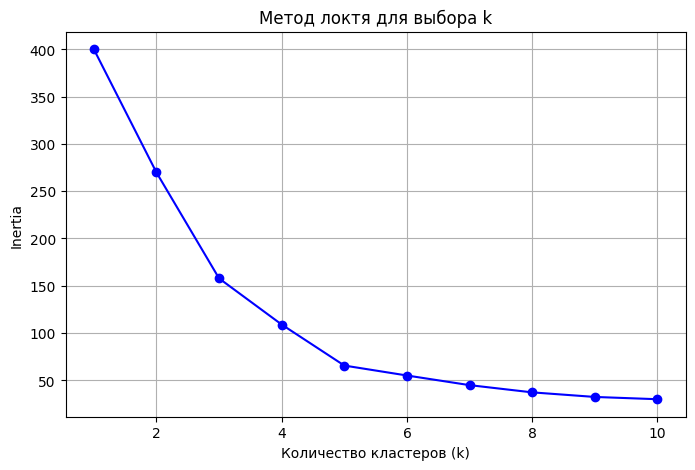

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# k_means = KMeans(n_clusters=3,random_state=RANDOM_STATE, n_init='auto').fit(X_scaled)
k_range = range(1, 11)
inertia = []

for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia')
plt.title('Метод локтя для выбора k')
plt.grid(True)


In [9]:
silhouette_scores = []

for k in range(2, 11):  # Силуэт не считается для k=1
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette_score={score:.3f}")

# Лучший k - тот, где score максимальный
best_k = range(2, 11)[np.argmax(silhouette_scores)]
print(f"Лучший k по силуэту: {best_k}")

k=2, silhouette_score=0.321
k=3, silhouette_score=0.467
k=4, silhouette_score=0.494
k=5, silhouette_score=0.555
k=6, silhouette_score=0.540
k=7, silhouette_score=0.528
k=8, silhouette_score=0.455
k=9, silhouette_score=0.457
k=10, silhouette_score=0.443
Лучший k по силуэту: 5


In [12]:
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add clusters to original dataset
dataset["Cluster"] = clusters

# Look on cluster's center (original zoom)
center = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(center, columns=["Income", "Spending"])
print(f"Центы кластеров: {centers_df}")


Центы кластеров:       Income   Spending
0  55.296296  49.518519
1  86.538462  82.128205
2  25.727273  79.363636
3  88.200000  17.114286
4  26.304348  20.913043


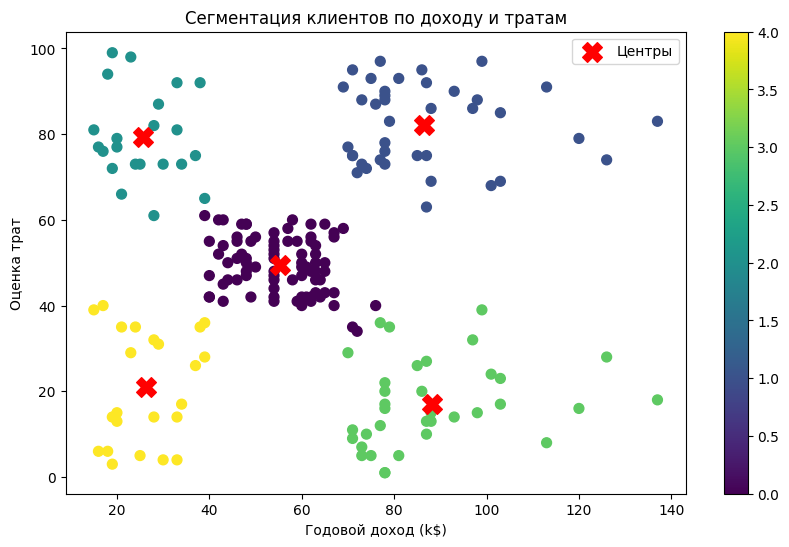

In [21]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(dataset['Annual Income (k$)'], 
                     dataset['Spending Score (1-100)'], 
                     c=dataset['Cluster'], 
                     cmap='viridis', 
                     s=50)
plt.scatter(center[:, 0], center[:, 1], 
           c='red', marker='X', s=200, label='Центры')
plt.xlabel('Годовой доход (k$)')
plt.ylabel('Оценка трат')
plt.title('Сегментация клиентов по доходу и тратам')
plt.colorbar(scatter)
plt.legend()
plt.show()